In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("../mpl_themes/jvc.mplstyle")
GALLERY = "/home/jvc/ZnO_database/gallery"

## Estrutura de Bandas e DOS

In [2]:
# bands
bands = np.loadtxt(
    "/home/jvc/ZnO_database/DFT_LDA/03_band_structure/pp_bands/ZnO_LDA_noU_bands.dat.gnu"
)
k = np.unique(bands[:, 0])
energy_b = np.reshape(bands[:, 1], (-1, k.size))

high_sym_points = [0.0000, 0.5774, 0.8888, 1.4661, 1.7776, 2.7958, 3.1072, 4.1255]
high_sym_labels = [r"$\Gamma$", r"K", "L", "A", r"$\Gamma$", "K", "H", "A"]

high_occ = 10.1075
lowest_unocc = 10.9776

In [3]:
# dos
energy_d, dos, idos = np.loadtxt(
    "/home/jvc/ZnO_database/DFT_LDA/04_density_of_states/pp_dos/ZnO.dos.dat",
    unpack=True,
)

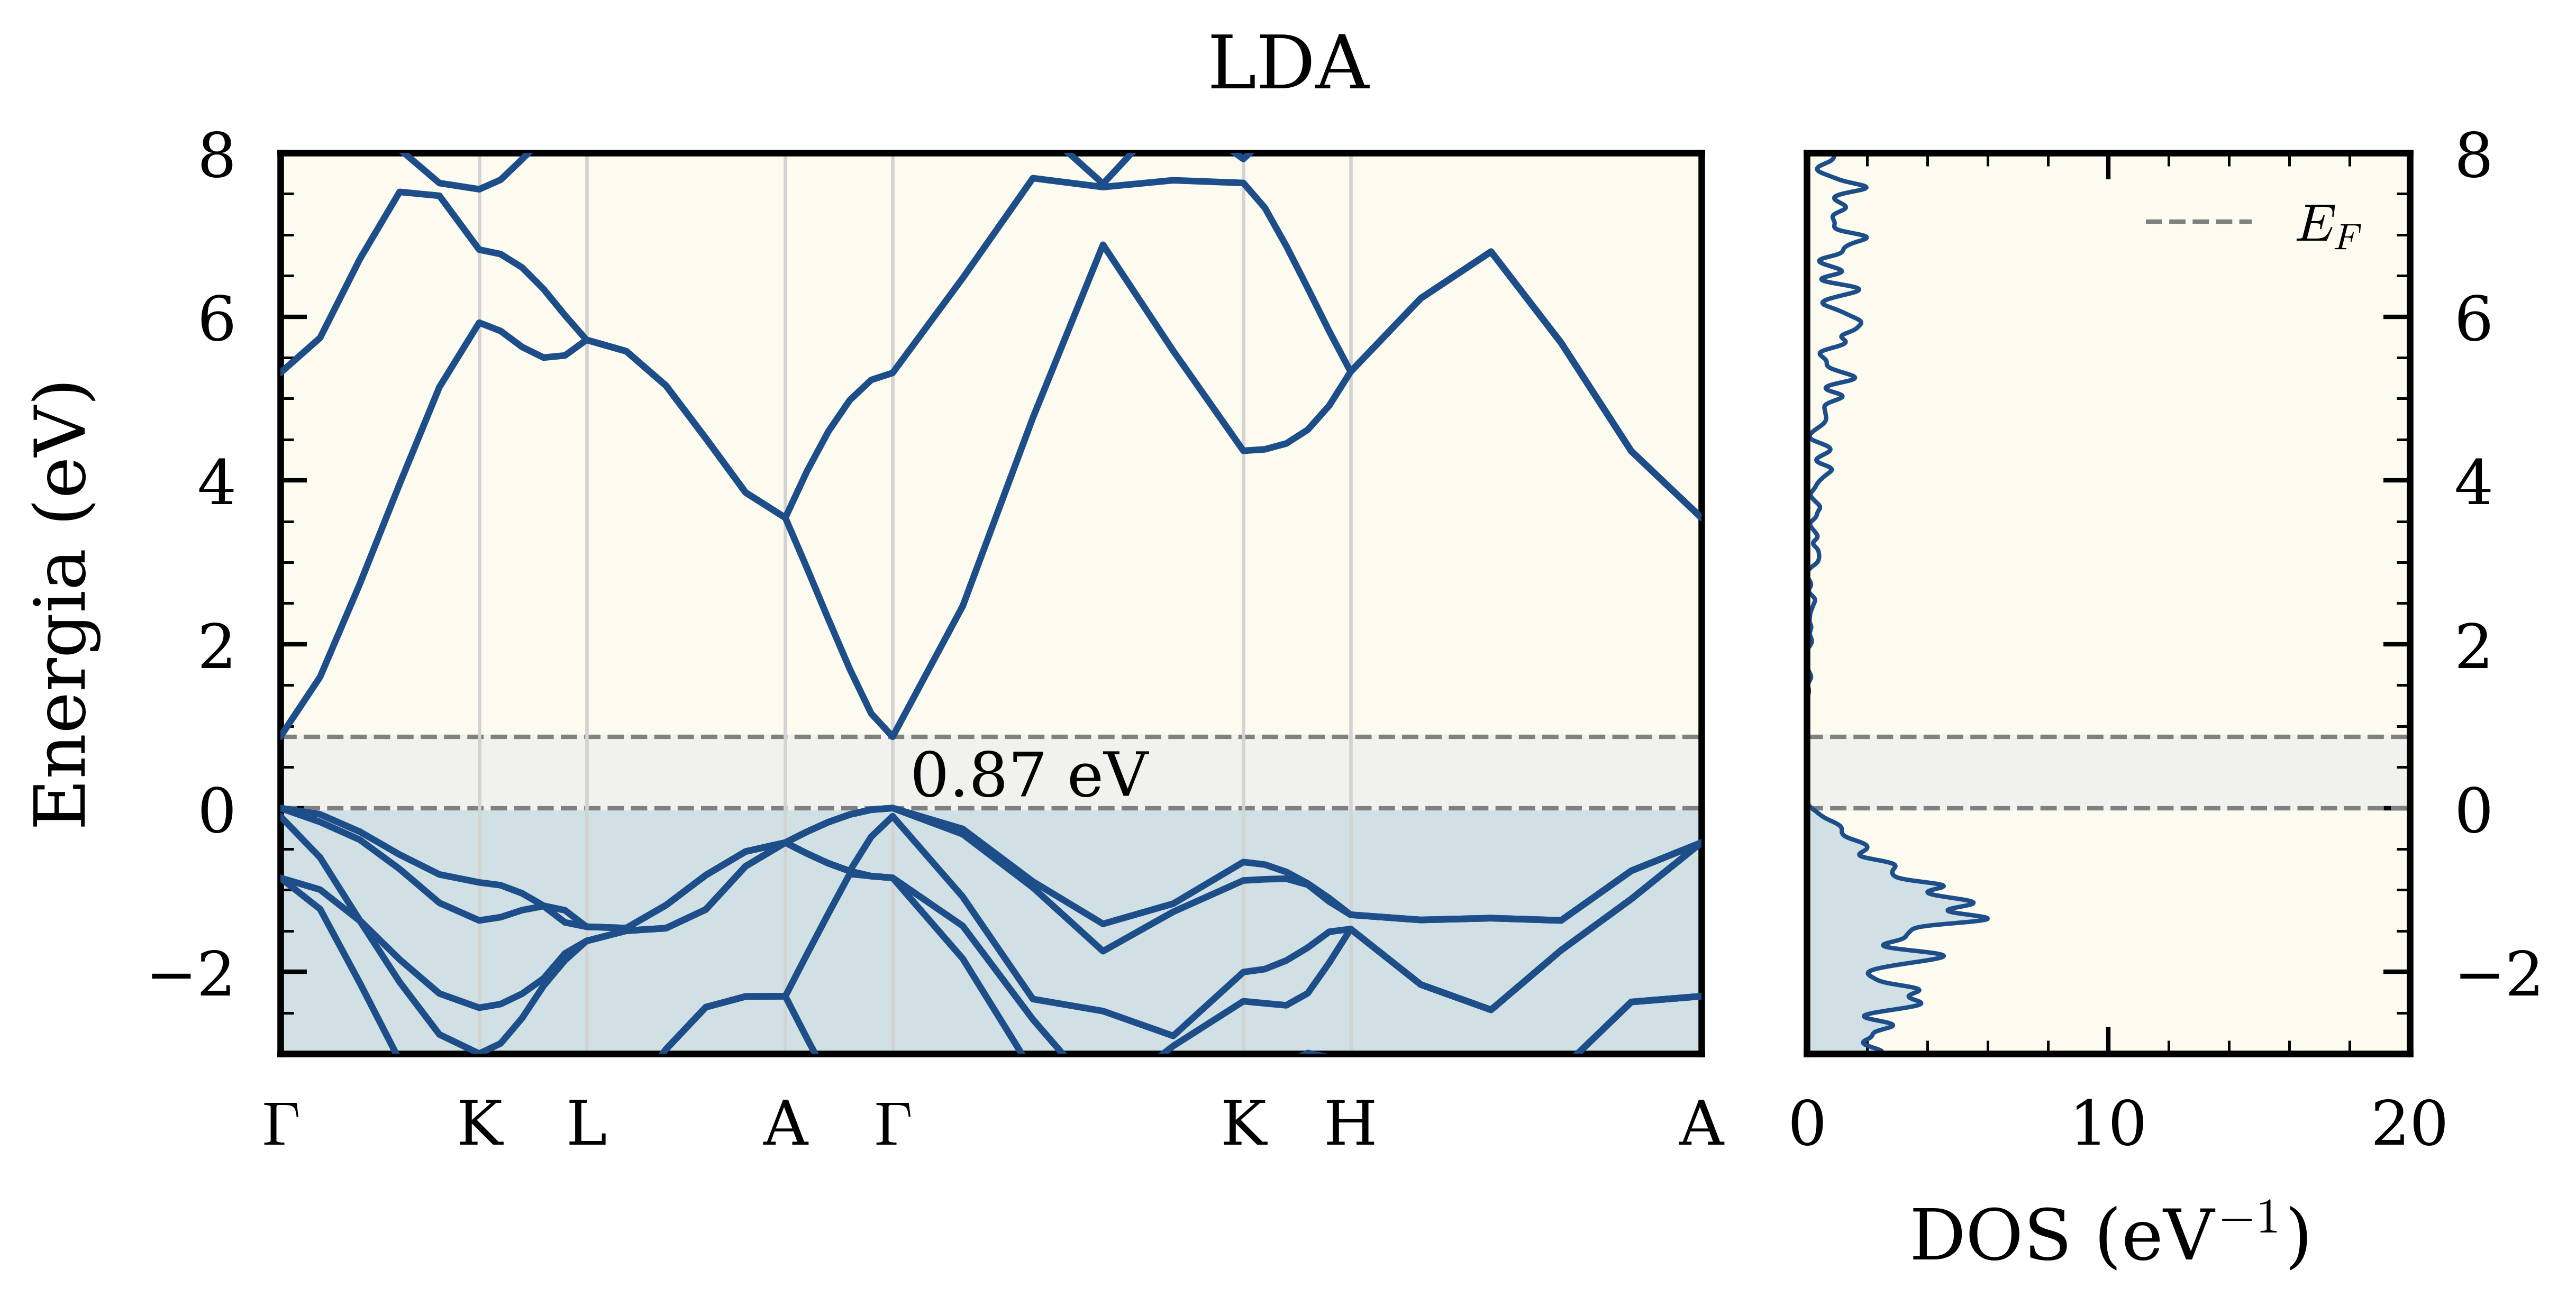

In [4]:
BLUE = "#1D4E89"

fig, (ax_bands, ax_dos) = plt.subplots(
    ncols=2,
    figsize=(8, 4),
    dpi=600,
    gridspec_kw={"width_ratios": [3.3, 1.4], "wspace": 0.05},
    sharey=True,
    layout="constrained",
)

fig.suptitle("LDA")
E_cbm = lowest_unocc - high_occ  # valor do gap com Ef = 0

# Linha do nível de Fermi
for ax in (ax_bands, ax_dos):
    ax.axhline(0.0, ls="--", lw=1.0, color="gray", label=r"$E_F$", zorder=2)
    ax.axhline(E_cbm, ls="--", lw=1.0, color="gray")
    ax.axhspan(0, E_cbm, color="#F1F2EE")

ax_bands.text(x=high_sym_points[4] + 5e-2, y=0.15, s=f"{E_cbm:.2f} eV")

# ax_bands.set_facecolor('white')
ax_bands.set_ylim(-3, 8)
ax_bands.set_xlim(k.min(), k.max())

ax_bands.set_ylabel("Energia (eV)")
ax_bands.set_xlabel("")

ax_bands.tick_params(axis="x", which="both", top=False, bottom=False)
ax_bands.tick_params(axis="both", which="both", top=False, bottom=False, right=False)
ax_bands.set_xticks(high_sym_points)
ax_bands.set_xticklabels(high_sym_labels)


for p in high_sym_points:
    ax_bands.axvline(p, color="lightgray", linewidth=0.8)

for band in range(len(energy_b)):
    ax_bands.plot(k, energy_b[band, :] - high_occ, linewidth=1.5, color=BLUE, zorder=3)


ax_bands.axhspan(0, -4, alpha=0.20, zorder=0)


# DENSIDADE DE ESTADOS
# ax_dos.set_facecolor('white')
ax_dos.yaxis.set_ticks_position("right")
ax_dos.yaxis.set_label_position("right")
ax_dos.tick_params(axis="y", which="both", left=False)
ax_dos.set_xlabel(r"DOS (eV$^{-1}$)")
ax_dos.set_xlim(0, 20)


ax_dos.plot(dos, energy_d - high_occ, color=BLUE, linewidth=1.0)
ax_dos.fill_betweenx(
    (energy_d - high_occ),
    0.0,
    dos,
    where=((energy_d - high_occ) <= 0),
    alpha=0.20,
    interpolate=True,
)
ax.legend()

plt.savefig(f"{GALLERY}/bands_and_dos_LDANC.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Densidade de Estados Projetada

_setup do pós-processamento_ com `dos.x`e `projwfc.x` 

```Fortran
degauus = 0.005
DeltaE = 0.01
```

In [5]:
def data_loader(fname) -> tuple[np.ndarray, np.ndarray]:
    """Load Energy and Ldos columns total contribution for a given orbital"""
    data = np.loadtxt(fname)
    energy = data[:, 0]
    pdos = data[:, 1]

    return energy, pdos

In [6]:
! ls ../DFT_LDA/04_density_of_states/pp_dos/*pdos*

'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#1(Zn)_wfc#1(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#1(Zn)_wfc#2(p)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#1(Zn)_wfc#3(d)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#1(Zn)_wfc#4(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#2(Zn)_wfc#1(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#2(Zn)_wfc#2(p)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#2(Zn)_wfc#3(d)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#2(Zn)_wfc#4(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#3(O)_wfc#1(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#3(O)_wfc#2(p)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#4(O)_wfc#1(s)'
'../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#4(O)_wfc#2(p)'
 ../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_tot
 ../DFT_LDA/04_dens

In [7]:
# Zn d
e, zn1_d = data_loader(
    "../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#1(Zn)_wfc#3(d)"
)
_, zn2_d = data_loader(
    "../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#2(Zn)_wfc#3(d)"
)
zn_d = zn1_d + zn2_d

# O p
_, o1_p = data_loader(
    "../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#3(O)_wfc#2(p)"
)
_, o2_p = data_loader(
    "../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_atm#4(O)_wfc#2(p)"
)
o_p = o1_p + o2_p

_, dos_tot = data_loader("../DFT_LDA/04_density_of_states/pp_dos/ZnO_LDA_noU.pdos_tot")


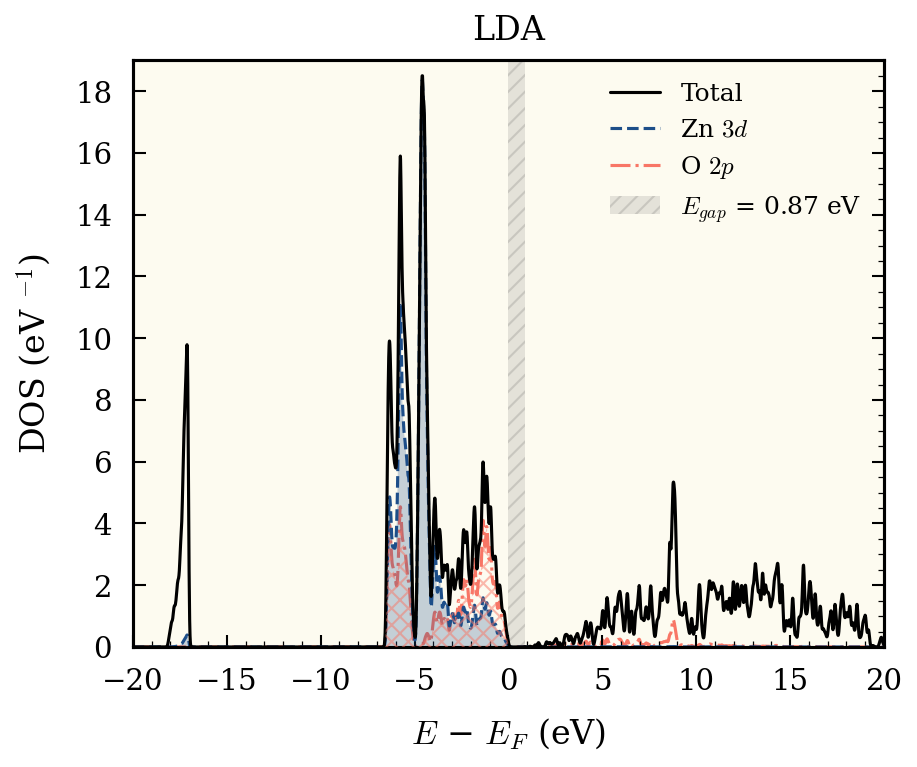

In [8]:
EFermi = 10.108

LIGHT_RED = "#F87666"
DARK_BLUE = "#1D4E89"
GREEN = "#629677"

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.set_title("LDA", pad=10)
ax.set_ylabel(r"DOS (eV $^{-1}$)")
ax.set_xlabel("$E$ − $E_F$ (eV)")
ax.set_xlim(-20, 20)
ax.set_ylim(0, 19)
# ax.set_yticks([])
ax.tick_params(which="both", top=False)
ax.tick_params(axis='y', which="minor", left=False)

ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.xaxis.set_major_locator(plt.MultipleLocator(5))

E = e - EFermi

ax.plot(E, dos_tot, color="black", label="Total", lw=1.5, zorder=3)
ax.plot(
    E,
    zn_d,
    color=DARK_BLUE,
    label="Zn $3d$",
    lw=1.5,
    ls="--",
    zorder=2,
)
ax.plot(
    E,
    o_p,
    color=LIGHT_RED,
    label="O $2p$",
    lw=1.5,
    ls="dashdot",
    zorder=1,
)

# Occupied States
to_fill = E < 0

# ax.fill_between(E, 0, dos_tot, where=to_fill, facecolor="gray", alpha=0.25, zorder=1)
ax.fill_between(E, 0, zn_d, where=to_fill, facecolor=DARK_BLUE, alpha=0.25, zorder=2)
ax.fill_between(E, 0, o_p, where=to_fill, facecolor="none", edgecolor=LIGHT_RED, hatch="xxx", lw=0.0, alpha=0.5, zorder=3)

# Fermi vertical line
Eg = 0.87
# ax.axvline(0, linestyle="--", linewidth=0.8, label=r"$E_F$", color=GREEN, zorder=10)


ax.axvspan(
    0.0,
    Eg,
    facecolor="gray",  # não pinta sólido
    edgecolor="0.35",  # cor da hachura/borda (cinza)
    hatch="///",
    lw=0.0,
    zorder=0,
    alpha=0.2,
    label=r"$E_{gap}$ = 0.87 eV"
)

ax.legend()
# Save Individual Contributions
# plt.savefig(f"{GALLERY}/O_p_states_pdos_LDANC.pdf", format="pdf")
# plt.savefig(f"{GALLERY}/Zn_d_states_pdos_LDANC.pdf", format="pdf")

plt.savefig(f"{GALLERY}/pdos_LDANC.pdf", format="pdf")
plt.show()


__Examplo__: https://pranabdas.github.io/espresso/hands-on/pdos/
```python
plt.fill_between(energy, 0, pdos_s, where=(energy < 7.9421), facecolor='#006699', alpha=0.25)
plt.fill_between(energy, 0, pdos_p, where=(energy < 7.9421), facecolor='r', alpha=0.25)
plt.fill_between(energy, 0, pdos_tot, where=(energy < 7.9421), facecolor='k', alpha=0.25)
```